In [ ]:
%pip install opencv-python ipywidgets

Task 1

In [1]:
ui desinging  
upload_btn = widgets.FileUpload(...)
color_dropdown = widgets.Dropdown(...)
process_btn = widgets.Button(...)
output_display = widgets.Output()

logic of color
def filter_color(image, color):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # ... defines lower and upper limits for colors ...
    mask = cv2.inRange(hsv, lower, upper)
    return cv2.bitwise_and(image, image, mask=mask)
    Download Link
    def create_download_link(img_bgr, filename="filtered_image.jpg"):
    # ... turns image into base64 string ...
    return HTML(html)
    button click
    def on_button_click(b):
    # ... the main sequence of events ...

SyntaxError: invalid syntax (4290930407.py, line 1)

In [9]:
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import base64

upload_btn = widgets.FileUpload(accept='.png, .jpg, .jpeg', multiple=False, description='Upload Image')
color_dropdown = widgets.Dropdown(
    options=['Blue', 'Green', 'Red', 'Orange'],
    value='Blue',
    description='Paint Spidey:'
)
process_btn = widgets.Button(description='Process & Download', button_style='success')
output_display = widgets.Output()

def paint_mask(image, target_color):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    lower1 = np.array([0, 30, 30])
    upper1 = np.array([10, 255, 255])
    lower2 = np.array([160, 30, 30])
    upper2 = np.array([180, 255, 255])
    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)
    mask = cv2.bitwise_or(mask1, mask2)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    painted_bgr = np.zeros_like(image)
    
    if target_color == 'Blue':
        painted_bgr[:, :, 0] = gray 
    elif target_color == 'Green':
        painted_bgr[:, :, 1] = gray 
    elif target_color == 'Red':
        painted_bgr[:, :, 2] = gray 
    elif target_color == 'Orange':
        painted_bgr[:, :, 1] = gray // 2
        painted_bgr[:, :, 2] = gray 

    mask_inv = cv2.bitwise_not(mask)
    
    color_part = cv2.bitwise_and(painted_bgr, painted_bgr, mask=mask)
    gray_part = cv2.bitwise_and(gray_bgr, gray_bgr, mask=mask_inv)
    
    return cv2.add(color_part, gray_part)

def create_download_link(img_bgr, filename="painted_spidey.jpg"):
    _, buffer = cv2.imencode('.jpg', img_bgr)
    b64 = base64.b64encode(buffer).decode()
    html = f'<a download="{filename}" href="data:image/jpeg;base64,{b64}" target="_blank" style="font-size: 16px; color: blue; text-decoration: underline;"><b>Click here to download your image!</b></a>'
    return HTML(html)

def on_button_click(b):
    with output_display:
        clear_output(wait=True) 
        
        if not upload_btn.value:
            print("Please click 'Upload Image' first!")
            return
            
        uploaded_file = upload_btn.value
        if isinstance(uploaded_file, tuple):
            try:
                content = uploaded_file[0]['content']
            except TypeError:
                content = uploaded_file[0].content
        else:
            content = list(uploaded_file.values())[0]['content']

        nparr = np.frombuffer(content, np.uint8)
        img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img_bgr is None:
            print("Error: Could not read image data.")
            return

        selected_color = color_dropdown.value
        result_bgr = paint_mask(img_bgr, selected_color)

        _, result_buffer = cv2.imencode('.jpg', result_bgr)
        display_img = widgets.Image(value=result_buffer.tobytes(), format='jpg', width=500)
        
        print(f"Successfully painted mask: {selected_color}")
        display(display_img)
        display(create_download_link(result_bgr))

process_btn.on_click(on_button_click)
display(widgets.VBox([upload_btn, color_dropdown, process_btn, output_display]))

In [ ]:
!pip install opencv-python mediapipe

In [ ]:
import cv2
import mediapipe as mp

# 1. Initialize MediaPipe Hands module
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False, 
    max_num_hands=2, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.7
)
mp_draw = mp.solutions.drawing_utils

# 2. Define fingertips and their lower joints for comparison
# The tips of the index, middle, ring, and pinky fingers
finger_tips = [8, 12, 16, 20]

# 3. Open the default webcam
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break
        
    # Flip the frame horizontally for a natural selfie-view
    frame = cv2.flip(frame, 1)
    
    # Convert the BGR frame to RGB for MediaPipe processing
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Process the frame to find hand landmarks
    results = hands.process(rgb_frame)
    
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            fingers_up = 0
            
            # Extract landmark coordinates
            lm = hand_landmarks.landmark
            
            # Thumb Logic: Compare the thumb tip (4) to the joint below it (3) on the x-axis
            # Note: This basic logic assumes the right hand. 
            if lm[4].x < lm[3].x:
                fingers_up += 1
                
            # Other Fingers Logic: Compare tip y-coordinate to the joint below it
            for tip in finger_tips:
                # In OpenCV, y goes down as values increase, so a lower value means "higher" on screen
                if lm[tip].y < lm[tip - 2].y:
                    fingers_up += 1
            
            # Draw the landmarks and connections on the hand
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # Display the finger count on the screen
            cv2.putText(
                frame, 
                f'Fingers: {fingers_up}', 
                (20, 70), 
                cv2.FONT_HERSHEY_SIMPLEX, 
                2, 
                (0, 255, 0), 
                3
            )

    # Show the webcam feed in a window
    cv2.imshow("Hand and Finger Detection", frame)
    
    # Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 4. Clean up resources
cap.release()
cv2.destroyAllWindows()

In [ ]:
!pip install --user opencv-python mediapipe

In [ ]:
import cv2
import mediapipe as mp

# 1. Initialize MediaPipe Hands module
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False, 
    max_num_hands=2, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.7
)
mp_draw = mp.solutions.drawing_utils

# 2. Define fingertips and their lower joints for comparison
# The tips of the index, middle, ring, and pinky fingers
finger_tips = [8, 12, 16, 20]

# 3. Open the default webcam
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break
        
    # Flip the frame horizontally for a natural selfie-view
    frame = cv2.flip(frame, 1)
    
    # Convert the BGR frame to RGB for MediaPipe processing
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Process the frame to find hand landmarks
    results = hands.process(rgb_frame)
    
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            fingers_up = 0
            
            # Extract landmark coordinates
            lm = hand_landmarks.landmark
            
            # Thumb Logic: Compare the thumb tip (4) to the joint below it (3) on the x-axis
            # Note: This basic logic assumes the right hand. 
            if lm[4].x < lm[3].x:
                fingers_up += 1
                
            # Other Fingers Logic: Compare tip y-coordinate to the joint below it
            for tip in finger_tips:
                # In OpenCV, y goes down as values increase, so a lower value means "higher" on screen
                if lm[tip].y < lm[tip - 2].y:
                    fingers_up += 1
            
            # Draw the landmarks and connections on the hand
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # Display the finger count on the screen
            cv2.putText(
                frame, 
                f'Fingers: {fingers_up}', 
                (20, 70), 
                cv2.FONT_HERSHEY_SIMPLEX, 
                2, 
                (0, 255, 0), 
                3
            )

    # Show the webcam feed in a window
    cv2.imshow("Hand and Finger Detection", frame)
    
    # Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 4. Clean up resources
cap.release()
cv2.destroyAllWindows()

In [ ]:
import mediapipe
print(mediapipe.__file__)

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall opencv-python mediapipe

In [10]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

# 1. Download the required AI model file if it doesn't exist
model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Downloading the Hand Landmarker model. This only happens once...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# 2. Setup the new MediaPipe Tasks API
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.7
)
detector = vision.HandLandmarker.create_from_options(options)

# 3. Open the webcam
cap = cv2.VideoCapture(0)

# The tips of the index, middle, ring, and pinky fingers
finger_tips = [8, 12, 16, 20]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break
        
    # Flip for a natural selfie-view and convert to RGB
    frame = cv2.flip(frame, 1)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Convert OpenCV image to MediaPipe's new Image format
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    
    
    detection_result = detector.detect(mp_image)
    
    fingers_up = 0
    
    # If hands are detected in the frame
    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:
            
            # Thumb Logic
            if hand_landmarks[4].x < hand_landmarks[3].x:
                fingers_up += 1
                
            # Other Fingers Logic
            for tip in finger_tips:
                if hand_landmarks[tip].y < hand_landmarks[tip - 2].y:
                    fingers_up += 1
            
            # Draw the landmarks manually 
            h, w, _ = frame.shape
            for lm in hand_landmarks:
                # Convert normalized coordinates (0.0 to 1.0) to pixel coordinates
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(frame, (cx, cy), 6, (255, 0, 0), cv2.FILLED)
                
    # Display the finger count on the screen
    cv2.putText(
        frame, 
        f'Fingers: {fingers_up}', 
        (20, 70), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        2, 
        (0, 255, 0), 
        3
    )

    # Show the webcam feed in a window
    cv2.imshow("Hand and Finger Detection (New API)", frame)
    
    # Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 4. Clean up resources
cap.release()
cv2.destroyAllWindows()

In [12]:
import cv2
import mediapipe as mp

# 1. Hire the Hand Tracking AI (MediaPipe)
mp_hands = mp.solutions.hands
# We only want to track 1 hand to keep it fast, and we want high confidence (70%)
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

# 2. Load the Spiderman Image
# We resize it to 100x100 pixels so it fits on your finger
spidey_img = cv2.imread('Spiderman.png')
if spidey_img is None:
    print("Error: Could not find 'Spiderman.png'. Make sure it is in the same folder!")
    exit()
spidey_img = cv2.resize(spidey_img, (100, 100))

# Get the height and width of the spidey image (100, 100)
s_h, s_w, _ = spidey_img.shape

# 3. Turn on the Webcam (0 is usually your default laptop camera)
cap = cv2.VideoCapture(0)

print("Camera is turning on! Press 'q' on your keyboard to quit.")

while True:
    # Grab a frame from the webcam
    success, frame = cap.read()
    if not success:
        break
        
    # Flip the frame horizontally so it acts like a mirror
    frame = cv2.flip(frame, 1)
    
    # MediaPipe needs the image in RGB color space, but OpenCV uses BGR
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Send the image to the AI to find hands
    results = hands.process(img_rgb)
    
    # If the AI found a hand...
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            
            # Optional: Draw the skeleton connections on your hand
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
            # Get the coordinates for Landmark #8 (The tip of the Index Finger)
            index_finger_tip = hand_landmarks.landmark[8]
            
            # The AI gives us percentages (0.0 to 1.0). 
            # We multiply by the screen size to get actual pixel coordinates.
            h, w, c = frame.shape
            cx, cy = int(index_finger_tip.x * w), int(index_finger_tip.y * h)
            
            # 4. The Overlay Logic
            # We want to center the Spiderman image on the finger tip
            # We use try/except to prevent the app from crashing if your finger goes off the edge of the screen
            try:
                # Calculate the box where the image will go
                y1, y2 = cy - s_h//2, cy + s_h//2
                x1, x2 = cx - s_w//2, cx + s_w//2
                
                # Replace that box of pixels with the Spiderman pixels
                frame[y1:y2, x1:x2] = spidey_img
            except:
                # If the math fails (finger is off-screen), do nothing and don't crash
                pass

    # 5. Show the final result on the screen
    cv2.imshow("Spiderman Finger Tracker", frame)

    # 6. Listen for the 'q' key to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Clean up and turn off the camera when done
cap.release()
cv2.destroyAllWindows()

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [16]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

mask_path = 'spiderman.png'
spiderman_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

if spiderman_mask is None:
    print(f"CRITICAL ERROR: Could not load '{mask_path}'. Check the file name and location!")
    exit()
elif spiderman_mask.shape[2] != 4:
    print("CRITICAL ERROR: The image does not have an alpha channel (transparency).")
    exit()

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Downloading the Hand Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.7
)
detector = vision.HandLandmarker.create_from_options(options)

cap = cv2.VideoCapture(0)
finger_tips = [8, 12, 16, 20]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    frame = cv2.flip(frame, 1)
    
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(100, 100))
    
    for (x, y, w, h) in faces:
        y_offset = int(y - (h * 0.2))
        h_new = int(h * 1.4)
        x_offset = int(x - (w * 0.1))
        w_new = int(w * 1.2)
        
        if y_offset < 0 or x_offset < 0 or y_offset + h_new > frame.shape[0] or x_offset + w_new > frame.shape[1]:
            continue
            
        resized_mask = cv2.resize(spiderman_mask, (w_new, h_new))
        
        mask_rgb = resized_mask[:, :, :3]
        alpha_channel = resized_mask[:, :, 3] / 255.0
        inverse_alpha = 1.0 - alpha_channel
        
        for c in range(3):
            frame[y_offset:y_offset+h_new, x_offset:x_offset+w_new, c] = (
                alpha_channel * mask_rgb[:, :, c] + 
                inverse_alpha * frame[y_offset:y_offset+h_new, x_offset:x_offset+w_new, c]
            )

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    detection_result = detector.detect(mp_image)
    fingers_up = 0
    
    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:
            if hand_landmarks[4].x < hand_landmarks[3].x:
                fingers_up += 1
            for tip in finger_tips:
                if hand_landmarks[tip].y < hand_landmarks[tip - 2].y:
                    fingers_up += 1
            
            h_img, w_img, _ = frame.shape
            for lm in hand_landmarks:
                cx, cy = int(lm.x * w_img), int(lm.y * h_img)
                cv2.circle(frame, (cx, cy), 6, (0, 0, 255), cv2.FILLED)
                
    cv2.putText(
        frame, 
        f'Fingers: {fingers_up}', 
        (20, 70), 
        cv2.FONT_HERSHEY_SIMPLEX, 
        2, 
        (0, 255, 0),
        3
    )

    cv2.imshow("Spidey-Cam: Face & Hand AI", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
# 1. The Core Library (For image formats and base settings)
import mediapipe as mp

# 2. The New AI Engines (For the actual vision and tracking models)
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 3. Standard Helpers (Almost always paired with MediaPipe)
import cv2
import numpy as np

In [ ]:
import mediapipe as np


In [ ]:
!pip install --upgrade mediapipe opencv-python

In [ ]:
import cv2
import mediapipe as mp

# 1. Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

# 2. Load and resize the Spiderman Image
spidey_img = cv2.imread('Spiderman.png')

if spidey_img is None:
    print("Error: Could not find 'Spiderman.png'. Please ensure it's in the same folder as this notebook!")
else:
    # Resize to a clean 100x100 overlay size
    spidey_img = cv2.resize(spidey_img, (100, 100))
    s_h, s_w, _ = spidey_img.shape

    # 3. Start Webcam
    cap = cv2.VideoCapture(0)
    print("Camera active. Focus on the popup window and press 'q' to exit.")

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Failed to grab frame.")
            break

        # Flip horizontally for natural mirror view
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        # Convert to RGB for MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)

        # 4. Tracking and Overlay Logic
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Draw hand landmarks
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

                # Track index finger tip (Landmark #8)
                index_tip = hand_landmarks.landmark[8]
                cx, cy = int(index_tip.x * w), int(index_tip.y * h)

                # Define image boundaries around the fingertip
                y1, y2 = cy - s_h // 2, cy + s_h // 2
                x1, x2 = cx - s_w // 2, cx + s_w // 2

                # Safe bounding box check so it doesn't crash at the edges of the screen
                if y1 >= 0 and y2 <= h and x1 >= 0 and x2 <= w:
                    frame[y1:y2, x1:x2] = spidey_img

        # 5. Display window
        cv2.imshow("Spiderman Finger Tracker", frame)

        # Break loop with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Clean up
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
import cv2

# Direct sub-module imports to completely bypass the top-level 'solutions' bug
import mediapipe.python.solutions.hands as mp_hands
import mediapipe.python.solutions.drawing_utils as mp_draw

# 1. Initialize MediaPipe Hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

# 2. Load and resize the Spiderman Image
spidey_img = cv2.imread('Spiderman.png')

if spidey_img is None:
    print("Error: Could not find 'Spiderman.png'. Please ensure it's in the same folder as this notebook!")
else:
    # Resize to a clean 100x100 overlay size
    spidey_img = cv2.resize(spidey_img, (100, 100))
    s_h, s_w, _ = spidey_img.shape

    # 3. Start Webcam
    cap = cv2.VideoCapture(0)
    print("Camera active. Focus on the popup window and press 'q' to exit.")

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Failed to grab frame.")
            break

        # Flip horizontally for natural mirror view
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        # Convert to RGB for MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)

        # 4. Tracking and Overlay Logic
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Draw hand landmarks
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

                # Track index finger tip (Landmark #8)
                index_tip = hand_landmarks.landmark[8]
                cx, cy = int(index_tip.x * w), int(index_tip.y * h)

                # Define image boundaries around the fingertip
                y1, y2 = cy - s_h // 2, cy + s_h // 2
                x1, x2 = cx - s_w // 2, cx + s_w // 2

                # Safe bounding box check so it doesn't crash at the edges of the screen
                if y1 >= 0 and y2 <= h and x1 >= 0 and x2 <= w:
                    frame[y1:y2, x1:x2] = spidey_img

        # 5. Display window
        cv2.imshow("Spiderman Finger Tracker", frame)

        # Break loop with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Clean up
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
import sys
import cv2

# Forcefully clear any broken 'mediapipe' modules stuck in Jupyter's memory cache
for module_name in list(sys.modules.keys()):
    if 'mediapipe' in module_name:
        sys.modules.pop(module_name, None)

# Import the direct solution backends directly to guarantee they load
import mediapipe.solutions.hands as mp_hands
import mediapipe.solutions.drawing_utils as mp_draw

# 1. Initialize MediaPipe Hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

# 2. Load and resize the Spiderman Image
spidey_img = cv2.imread('Spiderman.png')

if spidey_img is None:
    print("Error: Could not find 'Spiderman.png'. Please ensure it's in the same folder as this notebook!")
else:
    # Resize to a clean 100x100 overlay size
    spidey_img = cv2.resize(spidey_img, (100, 100))
    s_h, s_w, _ = spidey_img.shape

    # 3. Start Webcam
    cap = cv2.VideoCapture(0)
    print("Camera active. Focus on the popup window and press 'q' to exit.")

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Failed to grab frame.")
            break

        # Flip horizontally for natural mirror view
        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        # Convert to RGB for MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)

        # 4. Tracking and Overlay Logic
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Draw hand landmarks
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

                # Track index finger tip (Landmark #8)
                index_tip = hand_landmarks.landmark[8]
                cx, cy = int(index_tip.x * w), int(index_tip.y * h)

                # Define image boundaries around the fingertip
                y1, y2 = cy - s_h // 2, cy + s_h // 2
                x1, x2 = cx - s_w // 2, cx + s_w // 2

                # Safe bounding box check so it doesn't crash at the edges of the screen
                if y1 >= 0 and y2 <= h and x1 >= 0 and x2 <= w:
                    frame[y1:y2, x1:x2] = spidey_img

        # 5. Display window
        cv2.imshow("Spiderman Finger Tracker", frame)

        # Break loop with 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Clean up
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
!pip install cvzone mediapipe opencv-python --force-reinstall

In [ ]:
import mediapipe as mp
print(mp.__version__)
print(mp.__file__)

In [ ]:
import mediapipe as mp

print(mp.__version__)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

print("MediaPipe Hands loaded successfully!")


In [ ]:
import mediapipe as mp

print(mp.__version__)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

print("MediaPipe Hands loaded successfully!")

In [ ]:
import mediapipe as mp

print(mp)
print(mp.__file__)
print(dir(mp))

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

In [ ]:
!pip uninstall -y mediapipe

In [ ]:
!pip install mediapipe==0.10.14

In [ ]:
import sys
print(sys.version)


In [ ]:
import mediapipe as mp

print(mp.__version__)
print(hasattr(mp, "solutions"))

In [ ]:
import sys
print(sys.executable)

In [ ]:
import mediapipe as mp

print(mp.__version__)
print(dir(mp))

In [ ]:
from mediapipe.tasks.python.vision import HandLandmarker
print("HandLandmarker imported successfully")

In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

print("Hand detector loaded successfully!")

In [ ]:
Hand detector loaded successfully!

In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Load Hand Landmarker
base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task'
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

# Load Spider-Man image
spidey = cv2.imread("Spiderman.png")

if spidey is None:
    print("Spiderman.png not found!")
    exit()

spidey = cv2.resize(spidey, (100, 100))
s_h, s_w, _ = spidey.shape

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    success, frame = cap.read()

    if not success:
        break

    frame = cv2.flip(frame, 1)

    h, w, _ = frame.shape

    # Convert frame to MediaPipe Image
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = detector.detect(mp_image)

    if result.hand_landmarks:

        for hand in result.hand_landmarks:

            # Landmark 8 = index fingertip
            tip = hand[8]

            cx = int(tip.x * w)
            cy = int(tip.y * h)

            x1 = cx - s_w // 2
            y1 = cy - s_h // 2
            x2 = x1 + s_w
            y2 = y1 + s_h

            if x1 >= 0 and y1 >= 0 and x2 <= w and y2 <= h:
                frame[y1:y2, x1:x2] = spidey

            cv2.circle(frame, (cx, cy), 10, (0, 255, 0), -1)

    cv2.imshow("Spiderman Finger Tracker", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
import sys
print(sys.executable)

import mediapipe as mp
print(mp.__version__)
print(dir(mp))

In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task'
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

print("Hand detector loaded successfully!")

In [1]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ==========================
# Load Hand Landmarker
# ==========================
base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task'
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

# ==========================
# Load Face Detector
# ==========================
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# ==========================
# Load Spiderman Image
# ==========================
spidey = cv2.imread("Spiderman.png")

if spidey is None:
    print("Spiderman.png not found!")
    exit()

# ==========================
# Finger Counter Function
# ==========================
def count_fingers(hand):
    fingers = 0

    # Thumb
    if hand[4].x < hand[3].x:
        fingers += 1

    # Index
    if hand[8].y < hand[6].y:
        fingers += 1

    # Middle
    if hand[12].y < hand[10].y:
        fingers += 1

    # Ring
    if hand[16].y < hand[14].y:
        fingers += 1

    # Pinky
    if hand[20].y < hand[18].y:
        fingers += 1

    return fingers

# ==========================
# Start Camera
# ==========================
cap = cv2.VideoCapture(0)

while True:

    success, frame = cap.read()

    if not success:
        break

    frame = cv2.flip(frame, 1)

    h, w, _ = frame.shape

    # -------------------
    # FACE DETECTION
    # -------------------
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=5
    )

    for (x, y, fw, fh) in faces:

        try:
            spidey_face = cv2.resize(
                spidey,
                (fw, fh)
            )

            frame[y:y+fh, x:x+fw] = spidey_face

        except:
            pass

    # -------------------
    # HAND DETECTION
    # -------------------
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = detector.detect(mp_image)

    if result.hand_landmarks:

        for hand in result.hand_landmarks:

            finger_count = count_fingers(hand)

            cv2.putText(
                frame,
                f"Fingers: {finger_count}",
                (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2
            )

            # Draw fingertip
            tip = hand[8]

            cx = int(tip.x * w)
            cy = int(tip.y * h)

            cv2.circle(
                frame,
                (cx, cy),
                10,
                (0, 255, 0),
                -1
            )

    cv2.imshow(
        "Hand Counter + Spiderman Face",
        frame
    )

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
import mediapipe as mp
print(mp.__version__)


In [ ]:
!pip install mediapipe


--- Image Cropping Tool ---


Enter the name or path of your image file (e.g., photo.jpg):  Spiderman.png



Success! Loaded image with dimensions -> Height: 220px, Width: 220px

--- Enter Crop Dimensions ---


Enter the starting X coordinate (0 to max width):  50
Enter the starting Y coordinate (0 to max height):  50
Enter the width of the crop:  100
Enter the height of the crop:  100


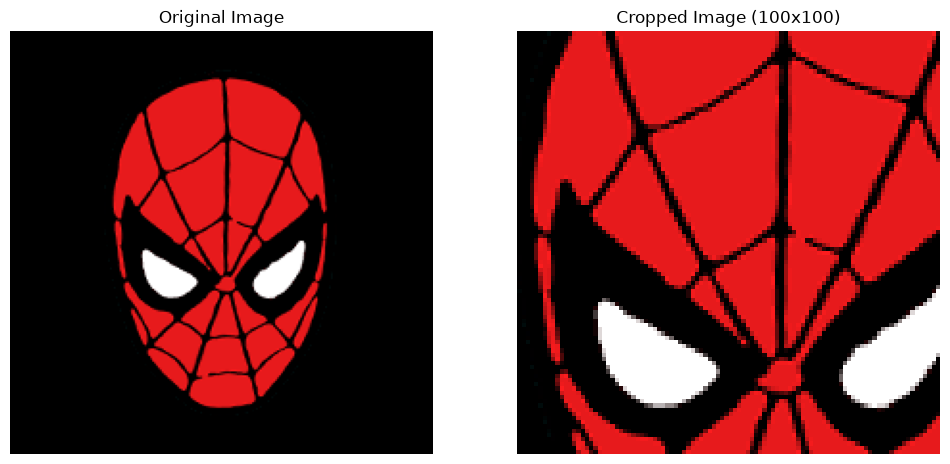

In [3]:
import cv2
import matplotlib.pyplot as plt
import os

print("--- Image Cropping Tool ---")
image_path = input("Enter the name or path of your image file (e.g., photo.jpg): ")

if not os.path.exists(image_path):
    print(f"Error: Could not find '{image_path}'. Please check the spelling and ensure it is in the same folder as this notebook.")
else:
    img = cv2.imread(image_path)
    
    if img is None:
         print("Error: The file was found, but OpenCV could not read it as an image.")
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width, channels = img.shape
        print(f"\nSuccess! Loaded image with dimensions -> Height: {height}px, Width: {width}px")
        
        try:
            print("\n--- Enter Crop Dimensions ---")
            start_x = int(input("Enter the starting X coordinate (0 to max width): "))
            start_y = int(input("Enter the starting Y coordinate (0 to max height): "))
            crop_width = int(input("Enter the width of the crop: "))
            crop_height = int(input("Enter the height of the crop: "))
            
            cropped_img = img_rgb[start_y : start_y + crop_height, start_x : start_x + crop_width]
            
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            
            axes[0].imshow(img_rgb)
            axes[0].set_title("Original Image")
            axes[0].axis('off') 
            
            axes[1].imshow(cropped_img)
            axes[1].set_title(f"Cropped Image ({crop_width}x{crop_height})")
            axes[1].axis('off')
            
            plt.show()

        except ValueError:
            print("Invalid input! Please enter whole numbers only for the coordinates and dimensions.")

In [5]:
import cv2
import os

print("--- Interactive Video Cropping Tool ---")

user_input = input("Enter your video file name (Press Enter for 'Aryanvid.mp4'): ")
video_path = user_input if user_input else "Aryanvid.mp4"

if not os.path.exists(video_path):
    print(f"Error: Could not find '{video_path}'. Make sure the file extension (like .mp4) is included!")
else:
   
    cap = cv2.VideoCapture(video_path)
    
   
    ret, first_frame = cap.read()
    
    if not ret:
        print("Error: Could not read the first frame of the video.")
    else:
        print("\nOpening the first frame... Please look for a new window.")
        print("INSTRUCTIONS:")
        print("1. Click and drag your mouse to draw a blue box.")
        print("2. Press 'SPACE' or 'ENTER' to confirm and start cropping the whole video.")
        print("3. Press 'c' to cancel and redraw.")
        

        roi = cv2.selectROI("Draw your crop box and press ENTER", first_frame, fromCenter=False, showCrosshair=True)
        cv2.destroyWindow("Draw your crop box and press ENTER")
        
       
        start_x = int(roi[0])
        start_y = int(roi[1])
        crop_width = int(roi[2])
        crop_height = int(roi[3])
        
     
        if crop_width > 0 and crop_height > 0:
            print(f"\nCrop area selected: {crop_width}x{crop_height} pixels.")
            print("Processing video... This might take a moment depending on the video length.")
            
            
            fps = cap.get(cv2.CAP_PROP_FPS)
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            output_path = "cropped_Aryanvid.mp4"
            
            out = cv2.VideoWriter(output_path, fourcc, fps, (crop_width, crop_height))
            
           
            cropped_first_frame = first_frame[start_y : start_y + crop_height, start_x : start_x + crop_width]
            out.write(cropped_first_frame)
            
            
            frame_count = 1
            while True:
                ret, frame = cap.read()
                if not ret:
                    break 
                
               
                cropped_frame = frame[start_y : start_y + crop_height, start_x : start_x + crop_width]
                out.write(cropped_frame)
                frame_count += 1
                
            
            cap.release()
            out.release()
            cv2.destroyAllWindows()
            
            print(f"\nSuccess! Processed {frame_count} frames.")
            print(f"Your fully cropped video has been saved as: '{output_path}'")
            
        else:
            print("\nNo crop box was drawn. Exiting.")
            cap.release()
            cv2.destroyAllWindows()

--- Interactive Video Cropping Tool ---


Enter your video file name (Press Enter for 'Aryanvid.mp4'):  



Opening the first frame... Please look for a new window.
INSTRUCTIONS:
1. Click and drag your mouse to draw a blue box.
2. Press 'SPACE' or 'ENTER' to confirm and start cropping the whole video.
3. Press 'c' to cancel and redraw.

Crop area selected: 351x192 pixels.
Processing video... This might take a moment depending on the video length.

Success! Processed 705 frames.
Your fully cropped video has been saved as: 'cropped_Aryanvid.mp4'
